In [1]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd

# Path to your project root (the folder that contains BOTH 'FR' and 'tool')
PROJECT_ROOT = os.path.abspath(".")

sys.path.append(PROJECT_ROOT)
# !python -m pip install matplotlib

# import pandas as pd


In [6]:
!which python

/opt/jupyterhub/bin/python


In [2]:

def set_seed(seed=42):
    # Python random
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic behavior (important)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Seed set to {seed}")

In [3]:
import os
import sys
set_seed(seed=42)
repo_path = '/content/Federated-Renyi'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

# Fix imports
files_to_patch = [
    './Federated-Renyi/FR/algorithm/FederatedRenyi.py',
    './Federated-Renyi/FR/algorithm/FederatedAverage.py',
    './Federated-Renyi/FR/algorithm/FederatedFair.py',
    './Federated-Renyi/FR/algorithm/LCO.py',
]

if os.path.exists('./Federated-Renyi/FR/algorithm/FederatedRenyi.py'):
    for filepath in files_to_patch:
        os.system(f"sed -i 's/^from tool.logger import \\*/from ..tool.logger import \\*/g' {filepath}")
        os.system(f"sed -i 's/^from tool.utils import/from ..tool.utils import/g' {filepath}")

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
import numpy as np
import json
import pickle
import statistics

from FR.hypothesis.LogisticRegression import RenyiLogisticRegression
from FR.hypothesis.NeuralNetwork import RenyiNeuralNetwork
from FR.moudle.dataset import get_ADULT_dataset, get_COMPAS_dataset, get_DRUG_dataset
from FR.moudle.dataloader import get_FL_dataloader
from FR.algorithm.FederatedRenyi import Fed_Renyi_NN, Fed_Renyi_LR
from FR.algorithm.FederatedAverage import Fed_AVG_NN, Fed_AVG_LR
from FR.algorithm.FederatedFair import Fed_Fair_NN, Fed_Fair_LR
from FR.algorithm.LCO import LCO_LR, LCO_NN
from FR.algorithm.FederatedRenyi import client_selection

def Experiment_Create_dataset(param_dict, no_pickle=False):
    dataset_name = param_dict['dataset_name']
    mask_s1_flag = param_dict['mask_s1_flag']
    mask_s2_flag = param_dict['mask_s2_flag']
    mask_s1_s2_flag = param_dict['mask_s1_s2_flag']

    BASE_DATA_PATH = "FR/dataset"

    if "ADULT" in dataset_name:
        pickle_path = os.path.join(BASE_DATA_PATH, "ADULT/ADULT.pickle")
        data_path = os.path.join(BASE_DATA_PATH, "ADULT")
        get_dataset = get_ADULT_dataset

    elif "COMPAS" in dataset_name:
        pickle_path = os.path.join(BASE_DATA_PATH, "COMPAS/COMPAS.pickle")
        data_path = os.path.join(BASE_DATA_PATH, "COMPAS")
        get_dataset = get_COMPAS_dataset

    else:
        pickle_path = os.path.join(BASE_DATA_PATH, "DRUG/DRUG.pickle")
        data_path = os.path.join(BASE_DATA_PATH, "DRUG")
        get_dataset = get_DRUG_dataset

    if not os.path.exists(pickle_path) or no_pickle:
        training_dataset, testing_dataset = get_dataset(
            data_path, mask_s1_flag, mask_s2_flag, mask_s1_s2_flag
        )

        with open(pickle_path, 'wb') as p:
            pickle.dump({
                "training_dataset": training_dataset,
                "testing_dataset": testing_dataset,
            }, p)

    else:
        with open(pickle_path, 'rb') as r:
            pickle_dict = pickle.load(r)

        training_dataset = pickle_dict['training_dataset']
        testing_dataset = pickle_dict['testing_dataset']

    nn_input_size = training_dataset.X.shape[1]
    return training_dataset, testing_dataset, nn_input_size


def Experiment_Create_dataloader(param_dict, training_dataset, testing_dataset):
    training_dataloaders, validation_dataloaders, client_dataset_list = get_FL_dataloader(
        training_dataset,
        param_dict['num_clients_K'],
        split_strategy="Uniform",
        do_train=True,
        need_validation=param_dict['need_validation'],
        batch_size=param_dict['batch_size'],
        num_workers=0,
        do_shuffle=True
    )

    testing_dataloader = get_FL_dataloader(
        testing_dataset,
        param_dict['num_clients_K'],
        split_strategy="Uniform",
        do_train=False,
        batch_size=param_dict['batch_size'],
        num_workers=0
    )

    return training_dataloaders, validation_dataloaders, client_dataset_list, testing_dataloader


def Experiment_Model_construction(param_dict, nn_input_size):
    if param_dict['hypothesis'] == "LR":
        model = RenyiLogisticRegression(input_size=nn_input_size)
    else:
        model = RenyiNeuralNetwork(input_size=nn_input_size, hidden_size=12)

    model.to(param_dict['device'])
    return model


def Experiment_Model_testing(device, testing_dataloader, mask_s1_flag, global_model, hypothesis):
    acc_numerator = 0
    acc_denominator = 0

    num_s1_pred1 = 0
    num_s1_pred0 = 0
    num_s0_pred1 = 0
    num_s0_pred0 = 0

    for batch in testing_dataloader:
        X = batch["X"].to(device)
        y = batch["y"].to(device)

        if hypothesis == "LR":
            pred = (global_model(X) >= 0.5).reshape(-1)
        else:
            pred = global_model(X).argmax(dim=1)

        acc_numerator += int(sum(pred.eq(y)))
        acc_denominator += X.shape[0]

        # s = batch["s2"] if mask_s1_flag else batch["s1"]

        # y_1 = (y == 1).int()
        # s_1 = (s == 1).int()
        # s_0 = (s == 0).int()
        # pred_1 = (pred == 1).int()
        # pred_0 = (pred == 0).int()
        s = batch["s2"].to(device) if mask_s1_flag else batch["s1"].to(device)

        y_1 = (y == 1).int().to(device)
        s_1 = (s == 1).int().to(device)
        s_0 = (s == 0).int().to(device)
        pred_1 = (pred == 1).int().to(device)
        pred_0 = (pred == 0).int().to(device)

        num_s1_pred1 += (y_1 * s_1 * pred_1).sum()
        num_s1_pred0 += (y_1 * s_1 * pred_0).sum()
        num_s0_pred1 += (y_1 * s_0 * pred_1).sum()
        num_s0_pred0 += (y_1 * s_0 * pred_0).sum()

    acc = acc_numerator / acc_denominator
    x1 = num_s1_pred1 / (num_s1_pred1 + num_s1_pred0)
    x2 = num_s0_pred1 / (num_s0_pred1 + num_s0_pred0)
    
    DEO = abs(x2 - x1)
    FR = 1 - DEO
    HM = statistics.harmonic_mean([float(acc), float(FR)])

    return float(acc), float(FR), float(HM)

    # DEO = abs(x2 - x1)
    # FR = 1 - DEO
    # HM = statistics.harmonic_mean([acc, float(FR)])

    # print(f"Accuracy: {acc:.4f}")
    # print(f"Fairness (FR): {FR:.4f}")
    # print(f"Harmonic Mean: {HM:.4f}")
def dp_sanity_check(model_full, model_removed, test_dl, device, hypothesis):
    diffs = []

    model_full.eval()
    model_removed.eval()

    with torch.no_grad():
        for batch in test_dl:
            X = batch["X"].to(device)

            if hypothesis == "LR":
                out1 = model_full(X)
                out2 = model_removed(X)
            else:
                out1 = torch.softmax(model_full(X), dim=1)
                out2 = torch.softmax(model_removed(X), dim=1)

            diff = torch.mean(torch.abs(out1 - out2)).item()
            diffs.append(diff)

    avg_diff = sum(diffs) / len(diffs)
    print(f"\n[DP SANITY CHECK] Avg output difference: {avg_diff:.6f}")
    return avg_diff


def combine_client_datasets(client_dataset_list):
    X_all, y_all, s1_all, s2_all = [], [], [], []
    new_client_list = []

    current_idx = 0

    for client in client_dataset_list:
        base = client.dataset
        idx = client.indices

        X = torch.tensor(base.X[idx], dtype=torch.float32)
        y = torch.tensor(base.y[idx], dtype=torch.long)
        s1 = torch.tensor(base.s1[idx], dtype=torch.long)
        s2 = torch.tensor(base.s2[idx], dtype=torch.long)

        X_all.append(X)
        y_all.append(y)
        s1_all.append(s1)
        s2_all.append(s2)

        # NEW indices (remapped)
        new_indices = list(range(current_idx, current_idx + len(idx)))

        # Create new Subset-like object
        class TempSubset:
            def __init__(self, indices):
                self.indices = indices
        
            def __len__(self):
                return len(self.indices)

        temp_subset = TempSubset(new_indices)

        new_client_list.append(temp_subset)

        current_idx += len(idx)

    class TempDataset:            
        def __len__(self):
            return self.X.shape[0]

        def __getitem__(self, idx):
            return {
                "X": self.X[idx],
                "y": self.y[idx],
                "s1": self.s1[idx],
                "s2": self.s2[idx],
            }

    new_dataset = TempDataset()
    new_dataset.X = torch.cat(X_all, dim=0)
    new_dataset.y = torch.cat(y_all, dim=0)
    new_dataset.s1 = torch.cat(s1_all, dim=0)
    new_dataset.s2 = torch.cat(s2_all, dim=0)

    return new_dataset, new_client_list
    communication_round_I = 3

   

def main(base_path, dataset_name, hypothesis, γ_k_style, device, fL_Fraction, epsilon_list = None):
    param_dict = {}

    with open(os.path.join(base_path, "COMMON.json"), "r") as f:
        param_dict.update(json.load(f))
    with open(os.path.join(base_path, dataset_name + ".json"), "r") as f:
        param_dict.update(json.load(f))

    param_dict['γ_k_style'] = γ_k_style
    param_dict['dataset_name'] = dataset_name
    # param_dict['algorithm'] = algorithm
    param_dict['hypothesis'] = hypothesis
    param_dict['device'] = "cuda" if ("gpu" in device and torch.cuda.is_available()) else "cpu"


    param_override = {
    'num_clients_K': 5,
    'batch_size': 32,
    'algorithm_epoch_T': 12,
    'communication_round_I': 6,
    'FL_drop_rate': 0.4,
    'lamda': 0.85,
    }
    param_dict.update(param_override)

    

    training_dataset, testing_dataset, nn_input_size = Experiment_Create_dataset(param_dict)
    train_dl, val_dl, client_list, test_dl = Experiment_Create_dataloader(
        param_dict, training_dataset, testing_dataset
    )
    
    # model = Experiment_Model_construction(param_dict, nn_input_size)

    # if "FederatedRenyi" in algorithm:
    #     model = Fed_Renyi_LR(
    #         param_dict['device'],
    #         param_dict['mask_s1_flag'],
    #         param_dict['lamda'],
    #         model,
    #         param_dict['algorithm_epoch_T'],
    #         param_dict['num_clients_K'],
    #         param_dict['communication_round_I'],
    #         param_dict['FL_fraction'],
    #         param_dict['FL_drop_rate'],
    #         param_dict['local_step_size'],
    #         train_dl,
    #         training_dataset,
    #         client_list,
    #         γ_k_style
    #     )

    # Experiment_Model_testing(param_dict['device'], test_dl, param_dict['mask_s1_flag'], model, hypothesis)
    results = []

    # -------- FedAvg --------
    # model_avg = Experiment_Model_construction(param_dict, nn_input_size)
    
    # model_avg = Fed_AVG_NN(
    #     param_dict['device'],
    #     model_avg,
    #     param_dict['algorithm_epoch_T'],
    #     param_dict['num_clients_K'],
    #     param_dict['communication_round_I'],
    #     param_dict['FL_fraction'],
    #     param_dict['FL_drop_rate'],
    #     param_dict['local_step_size'],
    #     train_dl,
    #     training_dataset,
    #     client_list
    # )
    
    # acc, fr, hm = Experiment_Model_testing(
    #     param_dict['device'], test_dl, param_dict['mask_s1_flag'], model_avg, hypothesis
    # )
    
    # results.append(("FedAvg", acc, fr, hm))
    
    param_dict.update({"FL_fraction":fL_Fraction})
    

    # -------- FedRenyi --------
    model_renyi = Experiment_Model_construction(param_dict, nn_input_size)
    
    model_renyi, dp_res = Fed_Renyi_NN(
    param_dict['device'],
    param_dict['mask_s1_flag'],
    param_dict['lamda'],
    model_renyi,
    param_dict['algorithm_epoch_T'],
    param_dict['num_clients_K'],
    param_dict['communication_round_I'],
    param_dict['FL_fraction'],
    param_dict['FL_drop_rate'],
    param_dict['local_step_size'],
    train_dl,
    training_dataset,
    client_list,
    γ_k_style,
    return_logs=True,
    use_dp = False,
    epsilons = epsilon_list
)


    # # -------- DP SANITY CHECK --------
    
    # # Remove last client
    # client_list_reduced = client_list[:-1]
    
    # train_dl_reduced = train_dl[:-1]  # same assumption (aligned lists)
    
    # # Train again with one client removed
    # model_removed = Experiment_Model_construction(param_dict, nn_input_size)
    # training_dataset_reduced, client_list_reduced = combine_client_datasets(client_list_reduced)
    
    # model_removed = Fed_Renyi_NN(
    #     param_dict['device'],
    #     param_dict['mask_s1_flag'],
    #     param_dict['lamda'],
    #     model_removed,
    #     param_dict['algorithm_epoch_T'],
    #     param_dict['num_clients_K'] - 1,  # IMPORTANT
    #     param_dict['communication_round_I'],
    #     param_dict['FL_fraction'],
    #     param_dict['FL_drop_rate'],
    #     param_dict['local_step_size'],
    #     train_dl_reduced,
    #     training_dataset_reduced,
    #     client_list_reduced,
    #     γ_k_style,
    #     epsilon=eps
    # )

    # dp_diff = dp_sanity_check(
    # model_renyi,
    # model_removed,
    # test_dl,
    # param_dict['device'],
    # hypothesis)
    
    acc, fr, hm = Experiment_Model_testing(
        param_dict['device'], test_dl, param_dict['mask_s1_flag'], model_renyi, hypothesis
    )

   
    results.append(("FedRenyi", acc, fr, hm))
    # -------- FedFair --------
    # model_fair = Experiment_Model_construction(param_dict, nn_input_size)
    
    # epsilon = 0.1  # keep simple
    
    # model_fair = Fed_Fair_NN(
    #     param_dict['device'],
    #     model_fair,
    #     param_dict['algorithm_epoch_T'],
    #     param_dict['num_clients_K'],
    #     train_dl,
    #     training_dataset,
    #     client_list,
    #     epsilon
    # )
    
    # acc, fr, hm = Experiment_Model_testing(
    #     param_dict['device'], test_dl, param_dict['mask_s1_flag'], model_fair, hypothesis
    # )
    
    # results.append(("FedFair", acc, fr, hm))
    print("\n===== RESULTS =====")
    print(f"{'Algorithm':<12} {'Accuracy':<10} {'Fairness':<10} {'HM':<10}")
    
    for name, acc, fr, hm in results:
        print(f"{name:<12} {acc:.4f}     {fr:.4f}     {hm:.4f}")
    return results, dp_res

# Example run
PATH = "FR/"

# Dataset = ["ADULT"]
# for i in Dataset:
#     main(PATH, i, "NN", "uniform", "gpu", fL_Fraction=0.5) 

Seed set to 42


/home/hari.prapan/HP/Hari_prapan/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
Dataset = ["ADULT"]

sc_diff_ = []

for i in Dataset:
    print("\n===== FEDRENYI (Baseline + Secure Check) =====")

    results = main(
        PATH,
        i,
        "NN",
        "uniform",
        "gpu",
        fL_Fraction=1,
    )

    sc_diff_.append(results)


===== FEDRENYI (Baseline + Secure Check) =====
2026-04-20 19:59:21,597 INFO    : Training process
2026-04-20 19:59:22,607 INFO    : ########## Epoch 1/12 | Client 1/5 ##########
2026-04-20 19:59:23,460 INFO    : ########## Epoch 1/12 | Client 2/5 ##########
2026-04-20 19:59:24,322 INFO    : ########## Epoch 1/12 | Client 3/5 ##########
2026-04-20 19:59:25,263 INFO    : ########## Epoch 1/12 | Client 4/5 ##########
2026-04-20 19:59:26,191 INFO    : ########## Epoch 1/12 | Client 5/5 ##########
2026-04-20 19:59:27,145 INFO    : ########## Epoch 2/12 | Client 1/5 ##########
2026-04-20 19:59:28,119 INFO    : ########## Epoch 2/12 | Client 2/5 ##########
2026-04-20 19:59:29,188 INFO    : ########## Epoch 2/12 | Client 3/5 ##########
2026-04-20 19:59:30,358 INFO    : ########## Epoch 2/12 | Client 4/5 ##########
2026-04-20 19:59:31,301 INFO    : ########## Epoch 2/12 | Client 5/5 ##########
2026-04-20 19:59:32,138 INFO    : ########## Epoch 3/12 | Client 1/5 ##########
2026-04-20 19:59:32,9

In [4]:
Dataset = ["ADULT"]

epsilon_list = [0.01, 0.1, 0.5, 1, 5, 10]

dp_diff_ = []

for i in Dataset:
    print("\n===== FEDRENYI (Baseline + DP) =====")

    results, dp_res = main(
        PATH,
        i,
        "NN",
        "uniform",
        "gpu",
        fL_Fraction=1,
        epsilon_list = epsilon_list
    )

    dp_diff_.append(results)



===== FEDRENYI (Baseline + DP) =====
2026-04-21 01:09:07,722 INFO    : Training process
2026-04-21 01:09:08,694 INFO    : ########## Epoch 1/12 | Client 1/5 ##########
2026-04-21 01:09:09,595 INFO    : ########## Epoch 1/12 | Client 2/5 ##########
2026-04-21 01:09:10,381 INFO    : ########## Epoch 1/12 | Client 3/5 ##########
2026-04-21 01:09:11,114 INFO    : ########## Epoch 1/12 | Client 4/5 ##########
2026-04-21 01:09:11,794 INFO    : ########## Epoch 1/12 | Client 5/5 ##########
2026-04-21 01:09:12,688 INFO    : ########## Epoch 2/12 | Client 1/5 ##########
2026-04-21 01:09:13,580 INFO    : ########## Epoch 2/12 | Client 2/5 ##########
2026-04-21 01:09:14,382 INFO    : ########## Epoch 2/12 | Client 3/5 ##########
2026-04-21 01:09:15,108 INFO    : ########## Epoch 2/12 | Client 4/5 ##########
2026-04-21 01:09:15,901 INFO    : ########## Epoch 2/12 | Client 5/5 ##########
2026-04-21 01:09:17,008 INFO    : ########## Epoch 3/12 | Client 1/5 ##########
2026-04-21 01:09:18,262 INFO   

In [13]:
Dataset = ["ADULT"]

epsilon_list = [0.01, 0.1, 0.5, 1, 5, 10]

dp_diff_ = []

for i in Dataset:
    print("\n===== FEDRENYI (Baseline + DP) =====")

    results, dp_res = main(
        PATH,
        i,
        "NN",
        "uniform",
        "gpu",
        fL_Fraction=1,
        epsilon_list = epsilon_list
    )

    dp_diff_.append(results)



===== FEDRENYI (Baseline + DP) =====
2026-04-22 14:36:11,710 INFO    : Training process
2026-04-22 14:36:12,091 INFO    : ########## Epoch 1/12 | Client 1/5 ##########
2026-04-22 14:36:13,329 INFO    : ########## Epoch 1/12 | Client 2/5 ##########
2026-04-22 14:36:14,473 INFO    : ########## Epoch 1/12 | Client 3/5 ##########
2026-04-22 14:36:15,473 INFO    : ########## Epoch 1/12 | Client 4/5 ##########
2026-04-22 14:36:16,526 INFO    : ########## Epoch 1/12 | Client 5/5 ##########
2026-04-22 14:36:17,569 INFO    : ########## Epoch 2/12 | Client 1/5 ##########
2026-04-22 14:36:18,554 INFO    : ########## Epoch 2/12 | Client 2/5 ##########
2026-04-22 14:36:19,513 INFO    : ########## Epoch 2/12 | Client 3/5 ##########
2026-04-22 14:36:20,326 INFO    : ########## Epoch 2/12 | Client 4/5 ##########
2026-04-22 14:36:21,150 INFO    : ########## Epoch 2/12 | Client 5/5 ##########
2026-04-22 14:36:21,976 INFO    : ########## Epoch 3/12 | Client 1/5 ##########
2026-04-22 14:36:22,799 INFO   

In [5]:
dp_res

{'epsilon': [0.01, 0.1, 0.5, 1, 5, 10, 0.01, 0.1, 0.5, 1, 5, 10],
 'fairness': [0.8146873712539673,
  0.8105803728103638,
  0.8120612502098083,
  0.8122158050537109,
  0.8119770288467407,
  0.8119754195213318,
  0.8413622379302979,
  0.8382910490036011,
  0.8392274379730225,
  0.839385986328125,
  0.8393604755401611,
  0.839361310005188],
 'baseline': [0.8119872808456421, 0.8393619060516357],
 'rounds': [1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2],
 'noise': [tensor([-0.0017,  0.0001,  0.0032,  0.0021, -0.0056,  0.0004]),
  tensor([-3.8074e-04, -7.1546e-07, -7.4316e-04,  3.5083e-04,  3.3661e-05,
           5.6734e-04]),
  tensor([-4.2941e-05,  6.6628e-05, -2.7984e-05, -6.2071e-05, -9.8110e-05,
          -1.8437e-05]),
  tensor([-4.6965e-05,  6.2133e-05,  2.8669e-05, -1.2624e-04, -1.6150e-05,
           7.1835e-06]),
  tensor([-1.7944e-05,  5.3118e-06, -6.5448e-06,  6.3358e-06,  2.1160e-06,
          -2.8302e-06]),
  tensor([ 4.3835e-06,  4.7144e-06, -8.6508e-06,  6.7357e-07,  1.9140e-07,

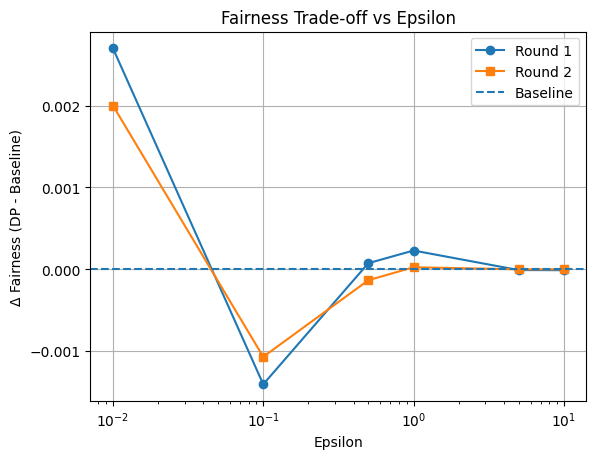

In [17]:
import matplotlib.pyplot as plt


n = len(dp_res["epsilon"])
half = n // 2
rounds = [1]*half + [2]*half

# Split by round
eps_r1 = dp_res["epsilon"][:half]
fair_r1 = dp_res["fairness"][:half]

eps_r2 = dp_res["epsilon"][half:]
fair_r2 = dp_res["fairness"][half:]

# Baselines
baseline_r1 = dp_res["baseline"][0]
baseline_r2 = dp_res["baseline"][1]

# Compute delta fairness (tradeoff)
delta_r1 = [f - baseline_r1 for f in fair_r1]
delta_r2 = [f - baseline_r2 for f in fair_r2]

# Plot
plt.figure()

plt.plot(eps_r1, delta_r1, marker='o', label="Round 1")
plt.plot(eps_r2, delta_r2, marker='s', label="Round 2")

plt.axhline(0, linestyle='--', label="Baseline")

plt.xscale("log")

plt.xlabel("Epsilon")
plt.ylabel("Δ Fairness (DP - Baseline)")
plt.title("Fairness Trade-off vs Epsilon")

plt.legend()
plt.grid(True)

plt.show()

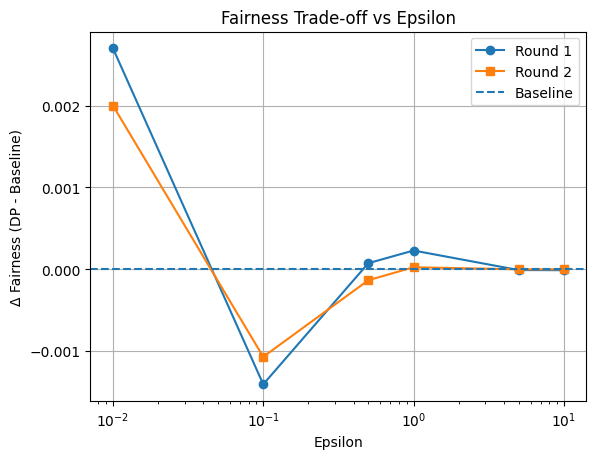

In [7]:
import matplotlib.pyplot as plt


n = len(dp_res["epsilon"])
half = n // 2
rounds = [1]*half + [2]*half

# Split by round
eps_r1 = dp_res["epsilon"][:half]
fair_r1 = dp_res["fairness"][:half]

eps_r2 = dp_res["epsilon"][half:]
fair_r2 = dp_res["fairness"][half:]

# Baselines
baseline_r1 = dp_res["baseline"][0]
baseline_r2 = dp_res["baseline"][1]

# Compute delta fairness (tradeoff)
delta_r1 = [f - baseline_r1 for f in fair_r1]
delta_r2 = [f - baseline_r2 for f in fair_r2]

# Plot
plt.figure()

plt.plot(eps_r1, delta_r1, marker='o', label="Round 1")
plt.plot(eps_r2, delta_r2, marker='s', label="Round 2")

plt.axhline(0, linestyle='--', label="Baseline")

plt.xscale("log")

plt.xlabel("Epsilon")
plt.ylabel("Δ Fairness (DP - Baseline)")
plt.title("Fairness Trade-off vs Epsilon")

plt.legend()
plt.grid(True)

plt.show()

In [4]:
Dataset = ["ADULT"]

sc_diff_ = []

for i in Dataset:
    print("\n===== FEDRENYI (Baseline + Secure Check) =====")

    results = main(
        PATH,
        i,
        "NN",
        "uniform",
        "gpu",
        fL_Fraction=1,
    )

    sc_diff_.append(results)


===== FEDRENYI (Baseline + Secure Check) =====
2026-04-22 14:37:42,531 INFO    : Training process
2026-04-22 14:37:43,766 INFO    : ########## Epoch 1/12 | Client 1/5 ##########
2026-04-22 14:37:44,655 INFO    : ########## Epoch 1/12 | Client 2/5 ##########
2026-04-22 14:37:45,645 INFO    : ########## Epoch 1/12 | Client 3/5 ##########
2026-04-22 14:37:46,403 INFO    : ########## Epoch 1/12 | Client 4/5 ##########
2026-04-22 14:37:47,155 INFO    : ########## Epoch 1/12 | Client 5/5 ##########
2026-04-22 14:37:47,905 INFO    : ########## Epoch 2/12 | Client 1/5 ##########
2026-04-22 14:37:48,649 INFO    : ########## Epoch 2/12 | Client 2/5 ##########
2026-04-22 14:37:49,411 INFO    : ########## Epoch 2/12 | Client 3/5 ##########
2026-04-22 14:37:50,160 INFO    : ########## Epoch 2/12 | Client 4/5 ##########
2026-04-22 14:37:50,924 INFO    : ########## Epoch 2/12 | Client 5/5 ##########
2026-04-22 14:37:51,683 INFO    : ########## Epoch 3/12 | Client 1/5 ##########
2026-04-22 14:37:52,4

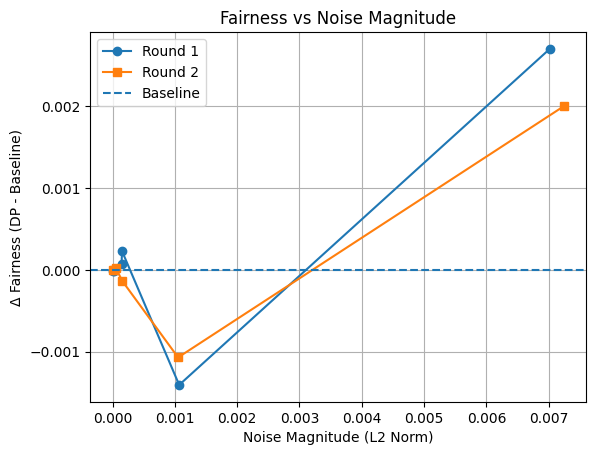

In [6]:
import torch
import matplotlib.pyplot as plt


# -------------------------
# Step 1: Convert noise → magnitude
# -------------------------
noise_mag = [torch.norm(n).item() for n in dp_res["noise"]]

# -------------------------
# Step 2: Split by round
# -------------------------
n = len(noise_mag)
half = n // 2

noise_r1 = noise_mag[:half]
noise_r2 = noise_mag[half:]

fair_r1 = dp_res["fairness"][:half]
fair_r2 = dp_res["fairness"][half:]

# -------------------------
# Step 3: Baselines
# -------------------------
baseline_r1 = dp_res["baseline"][0]
baseline_r2 = dp_res["baseline"][1]

# -------------------------
# Step 4: Compute Δ fairness
# -------------------------
delta_r1 = [f - baseline_r1 for f in fair_r1]
delta_r2 = [f - baseline_r2 for f in fair_r2]

# -------------------------
# Step 5: Sort by noise (important)
# -------------------------
pairs_r1 = sorted(zip(noise_r1, delta_r1))
pairs_r2 = sorted(zip(noise_r2, delta_r2))

noise_r1, delta_r1 = zip(*pairs_r1)
noise_r2, delta_r2 = zip(*pairs_r2)

# -------------------------
# Step 6: Plot
# -------------------------
plt.figure()

plt.plot(noise_r1, delta_r1, marker='o', label="Round 1")
plt.plot(noise_r2, delta_r2, marker='s', label="Round 2")

plt.axhline(0, linestyle='--', label="Baseline")

plt.xlabel("Noise Magnitude (L2 Norm)")
plt.ylabel("Δ Fairness (DP - Baseline)")
plt.title("Fairness vs Noise Magnitude")

plt.legend()
plt.grid(True)

plt.show()